In [1]:
import matplotlib.pyplot as plt
import numpy as np
import PSD_utils
import capillary_wave_analysis as cwa
from scipy.signal import welch
from scipy.io import loadmat

In [2]:
%load_ext autoreload
%autoreload 2

In [342]:
log2_xticks = np.array([4, 8, 16, 32, 64], dtype=float)    # x ticks for log2 scale

# Global plotting defaults
plt.rcParams.update({
    "figure.figsize": (7, 5),
    "axes.labelsize": 18,
    "axes.titlesize": 18,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 14,
    "lines.linewidth": 2,
    "grid.alpha": 0.4,
    "grid.linestyle": "--",
    "axes.grid": True,
})

FS_DHM = 115_200

In [ ]:
# file_path = '/disk/hyk049/WT_RomFit/0p04/0p04vpp_r=18_AB_amp10_sigma20.mat'
# file_path = '/disk/hyk049/WT_RomFit/0p04/0p04vpp_stoc_opinf_10datasets.mat'

# file_path = '/disk/hyk049/WT_RomFit/0p07/0p07vpp_r=8_ABN_amp10_sigma10.mat'
# file_path = '/disk/hyk049/WT_RomFit/0p07/0p07vpp_stoc_opinf_10datasets.mat'

# file_path = '/disk/hyk049/WT_RomFit/0p25/0p25vpp_r=19_ABN_amp1_sigma15.mat'
# file_path = '/disk/hyk049/WT_RomFit/0p25/0p25vpp_r=19_ABN_amp1_sigma10.mat'

# file_path = '/disk/hyk049/WT_RomFit/0p25/0p25vpp_r=19_ABN_amp1_sigma10_fc_5e3.mat'
# file_path = '/disk/hyk049/WT_RomFit/0p25/0p25vpp_r=19_AB_amp1_sigma1.mat'
# file_path = '/disk/hyk049/WT_RomFit/0p25/0p25vpp_r=19_ABN_amp1_sigma15_new.mat'
# file_path = '/disk/hyk049/WT_RomFit/0p25/0p25vpp_r=19_AB_amp1_sigma120_new.mat'
# file_path = '/disk/hyk049/WT_RomFit/0p25/0p25vpp_r=19_AB_amp1_sigma1_Hreg_1e3.mat'
# file_path = '/disk/hyk049/WT_RomFit/0p25/0p25vpp_stoc_opinf_10datasets.mat'

# file_path = '/disk/hyk049/WT_RomFit/0p08/0p08vpp_r=14_AB_amp1_sigma15.mat'

# file_path = '/disk/hyk049/WT_RomFit/0p10/0p10vpp_r=16_AB_amp10_sigma15.mat'
# file_path = '/disk/hyk049/WT_RomFit/0p10/0p10vpp_stoc_opinf_10datasets.mat'

# file_path = '/disk/hyk049/WT_RomFit/0p20/0p20vpp_r=18_ABN_amp1_sigma10_fc_5e4.mat'
# file_path = '/disk/hyk049/WT_RomFit/0p20/0p20vpp_stoc_opinf_10datasets.mat'
# file_path = '/disk/hyk049/WT_RomFit/0p20/0p20vpp_r=18_ABN_amp1_sigma15.mat'

# file_path = '/disk/hyk049/WT_RomFit/0p15/0p15vpp_r=13_ABN_amp1_sigma15.mat'
# file_path = '/disk/hyk049/WT_RomFit/0p15/0p15vpp_r=13_AB_amp1_sigma31_new.mat'
# file_path = '/disk/hyk049/WT_RomFit/0p15/0p15vpp_stoc_opinf_10datasets.mat'


data = loadmat(file_path)
EFOM = data['EFOM']
EROM_new = data['EROM_opt']

In [344]:
power = '0p25'
amp = 1
sigma = 12
ROM_form = 'ABN'
r = 19

file_path = f'/disk/hyk049/WT_RomFit/{power}/'

filename = f"{file_path}{power}vpp_r={r}_{ROM_form}_amp{amp}_sigma{sigma}_new.mat"
# filename = f"{file_path}{power}vpp_r={r}_{ROM_form}_amp{amp}_sigma{sigma}_fc_3e2.mat"

data = loadmat(filename)
EFOM = data['EFOM']
EROM_12 = data['EROM_opt']

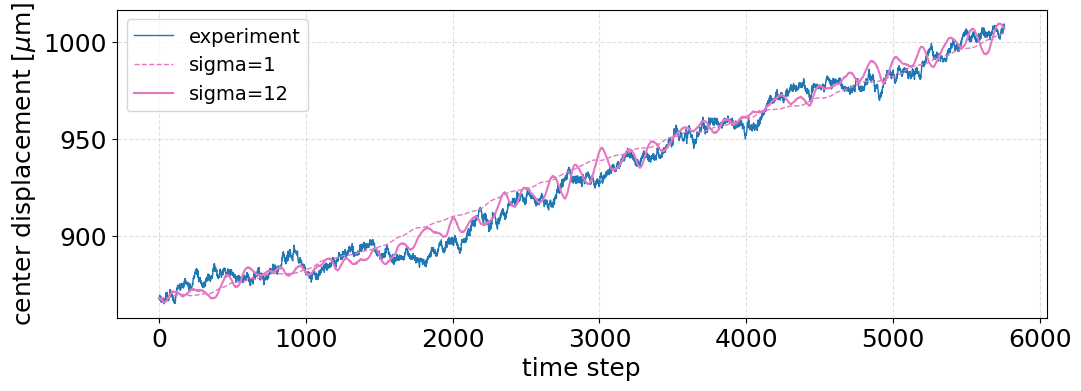

In [345]:
i_center = 100

plt.figure(figsize = (12,4))
plt.plot(EFOM[i_center,:], lw=1, color='C0', label="experiment")
plt.plot(EROM_1[i_center,:], lw=1, color='C6', ls="--", label="sigma=1")
plt.plot(EROM_12[i_center,:], lw=1.5, color='C6', ls="-", label=f"sigma={sigma}")

plt.xlabel("time step")
plt.ylabel(r"center displacement [$\mu$m]")
plt.legend()
plt.show()

In [447]:
# Preallocate PSD array
num_rows = EFOM.shape[0]   # 200
psd_FOM_all = []
psd_ROM_all = []

# Compute PSD for each row
for i in range(num_rows):
    k_FOM, psd_FOM, f_psd, *_ = PSD_utils.compute_PSD(EFOM[i,:], FS_DHM, 5, 30)
    k_ROM, psd_ROM, f_psd, *_ = PSD_utils.compute_PSD(EROM[i,:], FS_DHM, 5, 30)
    psd_FOM_all.append(psd_FOM)
    psd_ROM_all.append(psd_ROM)

psd_FOM = np.array(psd_FOM_all)   # shape: (200, len(k))
psd_ROM = np.array(psd_ROM_all)

# Compute mean PSD
psd_FOM_mean = np.mean(psd_FOM, axis=0)
psd_ROM_mean = np.mean(psd_ROM, axis=0)

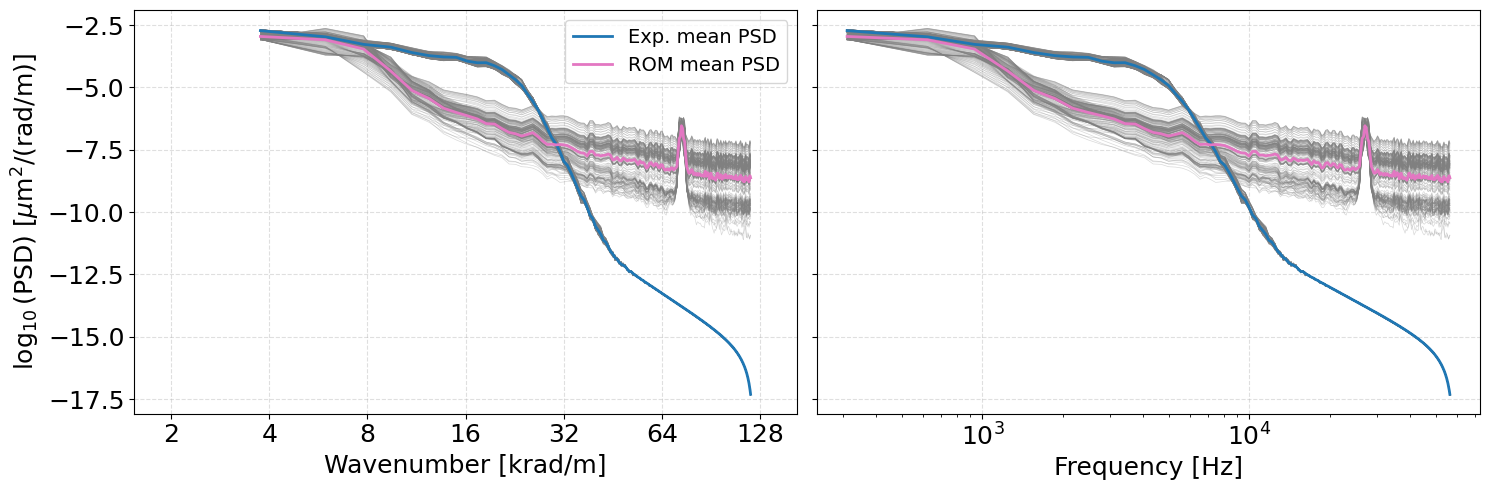

In [448]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

for i in range(num_rows):
    ax[0].plot(k_FOM, psd_FOM_all[i], color='grey', alpha=0.3, lw=0.5)
    ax[0].plot(k_ROM, psd_ROM_all[i], color='grey', alpha=0.3, lw=0.5)
    
    ax[1].plot(f_psd, psd_FOM_all[i], color='grey', alpha=0.3, lw=0.5)
    ax[1].plot(f_psd, psd_ROM_all[i], color='grey', alpha=0.3, lw=0.5)

ax[0].plot(k_FOM, psd_FOM_mean, color='C0', lw=2, label='Exp. mean PSD')
ax[0].plot(k_ROM, psd_ROM_mean, color='C6', lw=2, label='ROM mean PSD')

ax[1].plot(f_psd, psd_FOM_mean, color='C0', lw=2, label='Exp. mean PSD')
ax[1].plot(f_psd, psd_ROM_mean, color='C6', lw=2, label='ROM mean PSD')

ax[0].set_xscale('log', base=2)
ax[0].set_xlim(log2_xticks.min()/1.3, log2_xticks.max()*1.3)
ax[0].set_xticks(log2_xticks)
ax[0].set_xticklabels([str(int(x)) for x in log2_xticks], fontsize=18)
ax[0].tick_params(axis='y', labelsize=18)
ax[0].grid(True)
ax[0].legend(fontsize=14)

ax[1].set_xscale('log')

ax[0].set_xlabel("Wavenumber [krad/m]", fontsize=18)
ax[0].set_ylabel(r"$\log_{10}(\mathrm{PSD})$ [$\mu$m$^2$/(rad/m)]", fontsize=18)
ax[1].set_xlabel("Frequency [Hz]", fontsize=18)

plt.tight_layout()
plt.show()

In [350]:
# Compute PSD at the center point
i = 100

k_FOM, psd_FOM, f_FOM, slope_FOM, r2_FOM, i_best_FOM, j_best_FOM = PSD_utils.compute_PSD(EFOM[i,:], FS_DHM, 5, 10)
k_ROM, psd_ROM, f_ROM, slope_ROM, r2_ROM, i_best_ROM, j_best_ROM = PSD_utils.compute_PSD(EROM_1[i,:], FS_DHM, 5, 10)
k_ROM_new, psd_ROM_new, f_ROM_new, slope_ROM_new, r2_ROM, i_best_ROM, j_best_ROM = PSD_utils.compute_PSD(EROM_12[i,:], FS_DHM, 5, 10)

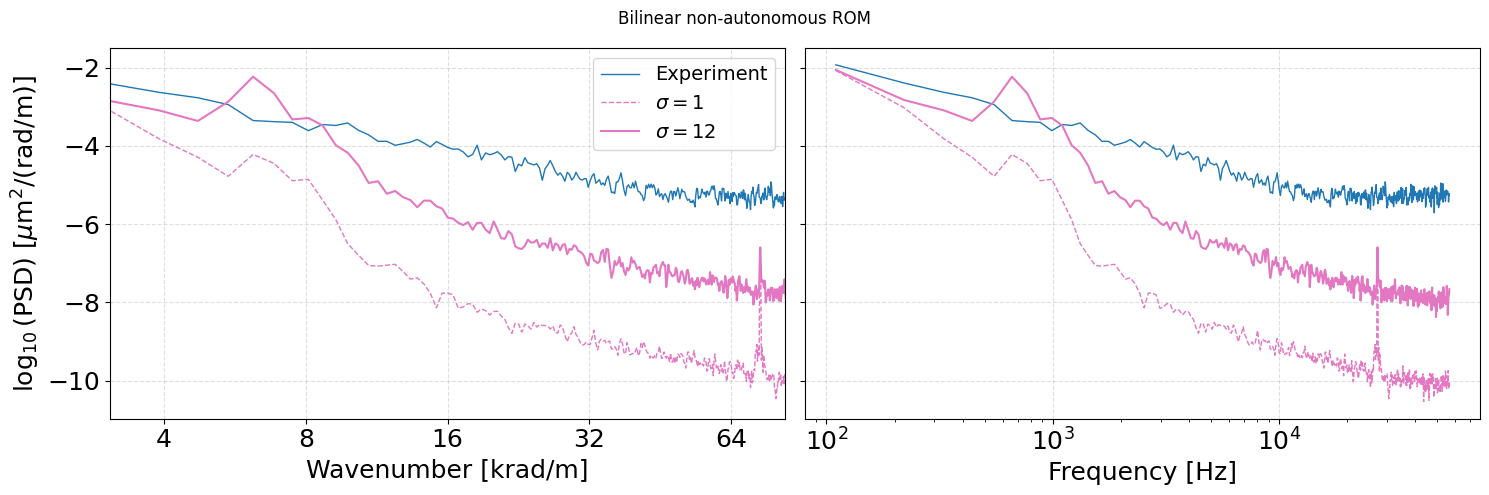

In [351]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

ax[0].plot(k_FOM, psd_FOM, color='C0', lw = 1, ls="-", label='Experiment')
ax[0].plot(k_ROM, psd_ROM, color='C6', lw = 1, ls="--", label=f'$\sigma = 1$')

ax[1].plot(f_FOM, psd_FOM, color='C0', lw = 1, ls="-", label='center point true PSD')
ax[1].plot(f_ROM, psd_ROM, color='C6', lw = 1, ls="--", label=f'$\sigma = 1$')

ax[0].plot(k_ROM_new, psd_ROM_new, color='C6', lw = 1.5, ls="-", label=f'$\sigma = {sigma}$')
ax[1].plot(f_ROM_new, psd_ROM_new, color='C6', lw = 1.5, ls="-", label=f'$\sigma = {sigma}$')

ax[0].set_xscale('log', base=2)
ax[0].set_xlim(log2_xticks.min()/1.3, log2_xticks.max()*1.3)
ax[0].set_xticks(log2_xticks)
ax[0].set_xticklabels([str(int(x)) for x in log2_xticks], fontsize=18)
ax[0].tick_params(axis='y', labelsize=18)
ax[0].grid(True)
ax[0].legend(fontsize=14)

# ax[0].set_ylim([-9.4, -2.8])

ax[1].set_xscale('log')

ax[0].set_xlabel("Wavenumber [krad/m]", fontsize=18)
ax[0].set_ylabel(r"$\log_{10}(\mathrm{PSD})$ [$\mu$m$^2$/(rad/m)]", fontsize=18)
ax[1].set_xlabel("Frequency [Hz]", fontsize=18)

if ROM_form == 'ABN':
    plt.suptitle("Bilinear non-autonomous ROM")
elif ROM_form == 'AB':
    plt.suptitle("Linear non-autonomous ROM")

plt.tight_layout()
plt.show()

In [337]:
10**(1/(np.sum(psd_ROM * psd_FOM) / np.sum(psd_ROM**2)))

np.float64(72.96803456721534)

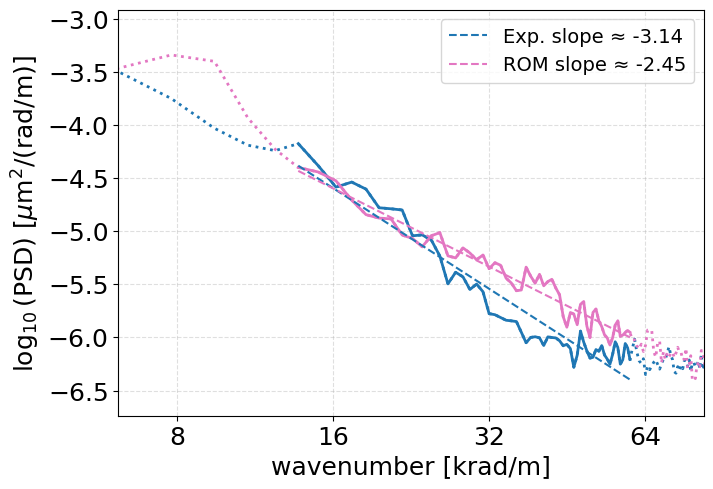

In [326]:
# fixed wavenumber range
kmin_FOM, kmax_FOM = 13, 60
kmin_ROM, kmax_ROM = 13, 60

slope_FOM, r2_FOM = PSD_utils.psd_slope_in_range(k_FOM, psd_FOM, kmin=kmin_FOM, kmax=kmax_FOM)
slope_ROM, r2_ROM = PSD_utils.psd_slope_in_range(k_ROM_new, psd_ROM_new, kmin=kmin_ROM, kmax=kmax_ROM)

# Masks for FOM and ROM
mask_FOM = (k_FOM >= kmin_FOM) & (k_FOM <= kmax_FOM)
mask_ROM = (k_ROM_new >= kmin_ROM) & (k_ROM_new <= kmax_ROM)

k_fit_FOM = k_FOM[mask_FOM]
k_fit_ROM = k_ROM_new[mask_ROM]

y_FOM = psd_FOM[mask_FOM]  # PSD already in log10
y_ROM = psd_ROM_new[mask_ROM]

# Intercepts for plotting slope lines
logk_FOM = np.log10(k_fit_FOM)
logk_ROM = np.log10(k_fit_ROM)

b_FOM = np.mean(y_FOM) - slope_FOM * np.mean(logk_FOM)
b_ROM = np.mean(y_ROM) - slope_ROM * np.mean(logk_ROM)

slope_line_FOM = slope_FOM * logk_FOM + b_FOM
slope_line_ROM = slope_ROM * logk_ROM + b_ROM

# Plot 
plt.figure()

# Full PSD curves
plt.plot(k_FOM, psd_FOM, color='C0', lw=2, ls=":")
plt.plot(k_ROM_new, psd_ROM_new, color='C6', lw=2, ls=":")

# Highlight fitted regions
plt.plot(k_fit_FOM, y_FOM, lw=2, color='C0')
plt.plot(k_fit_ROM, y_ROM, lw=2, color='C6')

# Plot slope lines
plt.plot(k_fit_FOM, slope_line_FOM, 'C0--', lw=1.5, label=f'Exp. slope ≈ {slope_FOM:.2f}')
plt.plot(k_fit_ROM, slope_line_ROM, 'C6--', lw=1.5, label=f'ROM slope ≈ {slope_ROM:.2f}')

# Annotate midpoint of fitted lines
mid_FOM = len(k_fit_FOM) // 2
# plt.text(
#     k_fit_FOM[mid_FOM],
#     slope_line_FOM[mid_FOM] + 0.05 * (slope_line_FOM.max() - slope_line_FOM.min()),
#     f"Slope ≈ {slope_FOM:.2f}",
#     color='C0', fontsize=14, ha='center', va='bottom'
# )

mid_ROM = len(k_fit_ROM) // 2
# plt.text(
#     k_fit_ROM[mid_ROM],
#     slope_line_ROM[mid_ROM] + 0.05 * (slope_line_ROM.max() - slope_line_ROM.min()),
#     f"Slope ≈ {slope_ROM:.2f}",
#     color='C6', fontsize=14, ha='right', va='top'  # bottom, center, top
# )

# Log-scale x-axis
plt.xscale('log', base=2)
plt.xlim(log2_xticks.min()/1.3, log2_xticks.max()*1.3)

ax = plt.gca()
ax.set_xticks(log2_xticks)
ax.set_xticklabels([str(int(x)) for x in log2_xticks])

plt.xlabel("wavenumber [krad/m]")
plt.ylabel(r"$\log_{10}(\mathrm{PSD})$ [$\mu$m$^2$/(rad/m)]")
plt.legend()
plt.tight_layout()
plt.show()

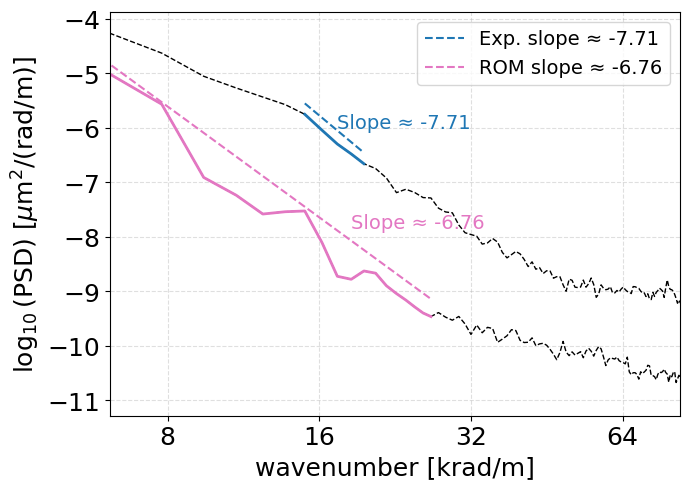

In [75]:
plt.figure()

plt.plot(k_FOM, psd_FOM, color='k', lw=1, ls="--")
plt.plot(k_ROM, psd_ROM, color='k', lw=1, ls="--")

# FOM best-fit + annotation
if i_best_FOM is not None and j_best_FOM is not None:
    k_fit_FOM = k_FOM[i_best_FOM:j_best_FOM+1]
    psd_fit_FOM = psd_FOM[i_best_FOM:j_best_FOM+1]

    # straight slope line
    k0 = k_fit_FOM[0]
    S0 = psd_fit_FOM[0]
    slope_line_FOM = slope_FOM * (np.log10(k_fit_FOM) - np.log10(k0)) + S0 + 0.2

    plt.plot(k_fit_FOM, slope_line_FOM, 'C0--', lw=1.5, label=f'Exp. slope ≈ {slope_FOM:.2f}')
    plt.plot(k_FOM[i_best_FOM:j_best_FOM+1], psd_FOM[i_best_FOM:j_best_FOM+1], lw=2, color='C0')

    # annotation
    mid = len(k_fit_FOM) // 2
    plt.text(
        k_fit_FOM[mid],
        slope_line_FOM[mid] + 0.05 * (slope_line_FOM.max() - slope_line_FOM.min()),
        f"Slope ≈ {slope_FOM:.2f}",
        color='C0',
        fontsize=14,
        ha='left'
    )

# ROM best-fit + annotation
if i_best_ROM is not None and j_best_ROM is not None:
    k_fit_ROM = k_ROM[i_best_ROM:j_best_ROM+1]
    psd_fit_ROM = psd_ROM[i_best_ROM:j_best_ROM+1]

    k0 = k_fit_ROM[0]
    S0 = psd_fit_ROM[0]
    slope_line_ROM = slope_ROM * (np.log10(k_fit_ROM) - np.log10(k0)) + S0 + 0.2

    plt.plot(k_fit_ROM, slope_line_ROM, 'C6--', lw=1.5, label=f'ROM slope ≈ {slope_ROM:.2f}')
    plt.plot(k_ROM[i_best_ROM:j_best_ROM+1], psd_ROM[i_best_ROM:j_best_ROM+1], lw=2, color='C6')

    mid = len(k_fit_ROM) // 2
    plt.text(
        k_fit_ROM[mid],
        slope_line_ROM[mid] + 0.05 * (slope_line_ROM.max() - slope_line_ROM.min()),
        f"Slope ≈ {slope_ROM:.2f}",
        color='C6',
        fontsize=14,
        ha='left'
    )
    
plt.xscale('log', base=2)
plt.xlim(log2_xticks.min() / 1.3, log2_xticks.max() * 1.3)

ax = plt.gca()
ax.set_xticks(log2_xticks)
ax.set_xticklabels([str(int(x)) for x in log2_xticks])
plt.xlabel("wavenumber [krad/m]")
plt.ylabel(r"$\log_{10}(\mathrm{PSD})$ [$\mu$m$^2$/(rad/m)]")
plt.legend()
plt.tight_layout()
plt.show()


In [102]:
h = 725*1e-6
1/h

1379.3103448275863

Spectral slope (total t): -7.98
r2 score (total t): 1.00


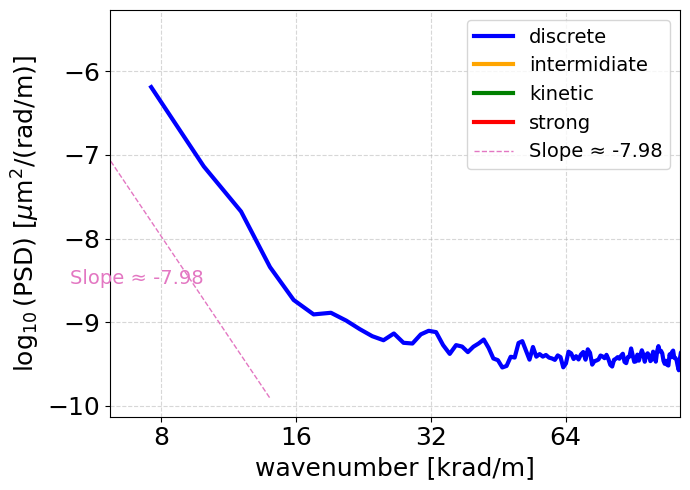

In [104]:
Q_test = EFOM

plt.figure(figsize=(7, 5))

# PSD
k_all, psd_all, slope, r2, i_best, j_best = PSD_utils.compute_PSD(Q_test[i, :], FS_DHM, 5)
print(f"Spectral slope (total t): {slope:.2f}")
print(f"r2 score (total t): {r2:.2f}")

plt.plot(k_all, psd_all, lw=1.5, color='k')

# ---- Welch PSD (Hann, 50% overlap, ~100 segments) ----
n = len(Q_test[i, :])
target_segments = 100
nperseg = max(256, int(2*n/(target_segments+1)))  
if nperseg % 2:
    nperseg -= 1

# Compute PSD
# -> spectral slope estimation
# -> inertial range identification
f, S_f = welch(Q_test[i, :], fs=FS_DHM, window="hann", nperseg=nperseg, noverlap=nperseg//2,
                return_onesided=True, scaling="density")

if f.size and f[0] == 0.0:
    f   = f[1:]
    S_f = S_f[1:]

# f -> k & Sf -> Sk
k = cwa.get_wavenumbers(f)
df_dk = PSD_utils.df_dk_from_k(k)
df_dk = np.where(np.isfinite(df_dk), df_dk, 0.0)
S_k = S_f * np.abs(df_dk)

log10_psd = np.log10(S_k)
k_krad = k / 1e3
k_log2 = np.log2(k_krad)

in_range = (k_krad >= PSD_utils.XMIN_RAW) & (k_krad <= PSD_utils.XMAX_RAW) & np.isfinite(k_log2)
k_log2 = k_log2[in_range]
k_krad = k_krad[in_range]
log10_psd = log10_psd[in_range]


# Amplitude spectrum (for regimes)
f_amp, amp_um = PSD_utils.amplitude_welch(Q_test[i, :], FS_DHM)

# Welch amplitude
amp_um_full = np.interp(f, f_amp, amp_um)
amp_um_full = amp_um_full[in_range]         
f_used = f[in_range]   

# Regime classification
kv, is_disc, is_meso, is_kin, is_str = cwa.get_regime_idxs(f_used, amp_um_full, no_strong=True)

# plot PSD by regime
regimes = [
    (is_disc, 'blue',   'discrete'),
    (is_meso, 'orange', 'intermidiate'),
    (is_kin,  'green',  'kinetic'),
    (is_str,  'red',    'strong'),
]

# for mask, color, label in regimes:
#     if np.any(mask):
#         plt.plot(k_krad[mask], log10_psd[mask],
#                  lw=2.5, color=color, label=label)

for mask, color, label in regimes:
    y_masked = np.full_like(log10_psd, np.nan)
    y_masked[mask] = log10_psd[mask]

    plt.plot(k_krad, y_masked, lw=3, color=color, label=label)

        
# --- Plot best-fit linear slope as a straight line above the colored PSD ---
if i_best is not None and j_best is not None:
    k_fit = k_krad[i_best:j_best+1]
    psd_fit = psd_all[i_best:j_best+1]

    # --- Dotted straight line showing slope ---
    # y = slope * (log10(k) - log10(k0)) + log10(S0)
    k0 = k_fit[0]
    S0 = psd_fit[0]
    slope_line = slope * (np.log10(k_fit) - np.log10(k0)) + S0
    plt.plot(k_fit, slope_line, 'C6--', lw=1, label=f"Slope ≈ {slope:.2f}")

    # Annotate slope above the line
    mid_idx = len(k_fit)//2
    plt.text(k_fit[mid_idx], slope_line[mid_idx] + 0.05*(slope_line.max()-slope_line.min()),
             f"Slope ≈ {slope:.2f}", color='C6', fontsize=14, ha='right')
    
plt.xscale('log', base=2)
plt.xlim(log2_xticks.min()/1.3, log2_xticks.max()*1.8)

ax = plt.gca()
ax.set_xticks(log2_xticks)
ax.set_xticklabels([str(int(x)) for x in log2_xticks], fontsize=18)

plt.tick_params(axis='y', labelsize=18)
plt.xlabel("wavenumber [krad/m]", fontsize=18)
plt.ylabel(r"$\log_{10}(\mathrm{PSD})$ [$\mu$m$^2$/(rad/m)]", fontsize=18)
plt.legend(fontsize=14)
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.tight_layout()
plt.show()


Spectral slope (total t): -7.95
r2 score (total t): 1.00


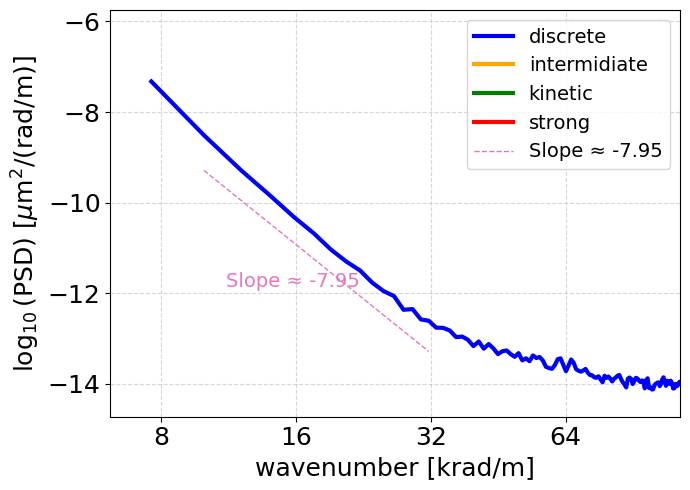

In [ ]:
Q_test = EROM

plt.figure(figsize=(7, 5))

# PSD
k_all, psd_all, slope, r2, i_best, j_best = PSD_utils.compute_PSD(Q_test[i, :], FS_DHM, 10)
print(f"Spectral slope (total t): {slope:.2f}")
print(f"r2 score (total t): {r2:.2f}")

plt.plot(k_all, psd_all, lw=1.5, color='k')

# ---- Welch PSD (Hann, 50% overlap, ~100 segments) ----
n = len(Q_test[i, :])
target_segments = 100
nperseg = max(256, int(2*n/(target_segments+1)))  
if nperseg % 2:
    nperseg -= 1

# Compute PSD
# -> spectral slope estimation
# -> inertial range identification
f, S_f = welch(Q_test[i, :], fs=FS_DHM, window="hann", nperseg=nperseg, noverlap=nperseg//2,
                return_onesided=True, scaling="density")

if f.size and f[0] == 0.0:
    f   = f[1:]
    S_f = S_f[1:]

# f -> k & Sf -> Sk
k = cwa.get_wavenumbers(f)
df_dk = PSD_utils.df_dk_from_k(k)
df_dk = np.where(np.isfinite(df_dk), df_dk, 0.0)
S_k = S_f * np.abs(df_dk)

log10_psd = np.log10(S_k)
k_krad = k / 1000.0
k_log2 = np.log2(k_krad)

in_range = (k_krad >= PSD_utils.XMIN_RAW) & (k_krad <= PSD_utils.XMAX_RAW) & np.isfinite(k_log2)
k_log2 = k_log2[in_range]
k_krad = k_krad[in_range]
log10_psd = log10_psd[in_range]


# Amplitude spectrum (for regimes)
f_amp, amp_um = PSD_utils.amplitude_welch(Q_test[i, :], FS_DHM)

# Welch amplitude
amp_um_full = np.interp(f, f_amp, amp_um)
amp_um_full = amp_um_full[in_range]         
f_used = f[in_range]   

# Regime classification
kv, is_disc, is_meso, is_kin, is_str = cwa.get_regime_idxs(f_used, amp_um_full, no_strong=True)

# plot PSD by regime
regimes = [
    (is_disc, 'blue',   'discrete'),
    (is_meso, 'orange', 'intermidiate'),
    (is_kin,  'green',  'kinetic'),
    (is_str,  'red',    'strong'),
]

# for mask, color, label in regimes:
#     if np.any(mask):
#         plt.plot(k_krad[mask], log10_psd[mask], lw=2.5, color=color, label=label)

for mask, color, label in regimes:
    y_masked = np.full_like(log10_psd, np.nan)
    y_masked[mask] = log10_psd[mask]

    plt.plot(k_krad, y_masked, lw=3, color=color, label=label)
        
# --- Plot best-fit linear slope as a straight line above the colored PSD ---
if i_best is not None and j_best is not None:
    k_fit = k_krad[i_best:j_best+1]
    psd_fit = psd_all[i_best:j_best+1]

    # --- Dotted straight line showing slope ---
    # y = slope * (log10(k) - log10(k0)) + log10(S0)
    k0 = k_fit[0]
    S0 = psd_fit[0]
    slope_line = slope * (np.log10(k_fit) - np.log10(k0)) + S0
    plt.plot(k_fit, slope_line, 'C6--', lw=1, label=f"Slope ≈ {slope:.2f}")

    # Annotate slope above the line
    mid_idx = len(k_fit)//2
    plt.text(k_fit[mid_idx], slope_line[mid_idx] + 0.05*(slope_line.max()-slope_line.min()),
             f"Slope ≈ {slope:.2f}", color='C6', fontsize=14, ha='right')
    
plt.xscale('log', base=2) # set xscale first and then set xticks
plt.xlim(log2_xticks.min()/1.3, log2_xticks.max()*1.8)

ax = plt.gca()
ax.set_xticks(log2_xticks)
ax.set_xticklabels([str(int(x)) for x in log2_xticks], fontsize=18)
plt.tick_params(axis='y', labelsize=18)
plt.xlabel("wavenumber [krad/m]", fontsize=18)
plt.ylabel(r"$\log_{10}(\mathrm{PSD})$ [$\mu$m$^2$/(rad/m)]", fontsize=18)
plt.legend(fontsize=14)
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.tight_layout()
plt.show()


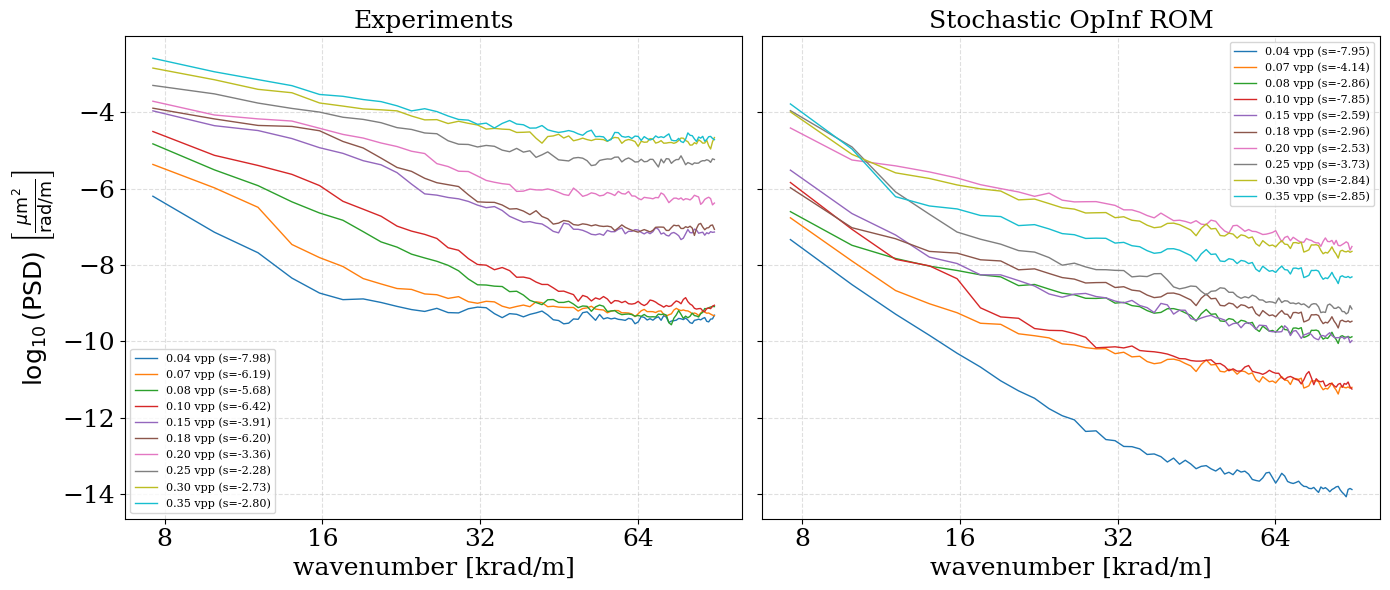

In [192]:
# All cases
vpp_cases = [
    "0p04", "0p07", "0p08", "0p10", "0p15", "0p18", "0p20", "0p25", "0p30", "0p35"
]

base_path = "/data/home/hyk049/Wave_Turbulence/"

i = 100  # center point index

# Containers if you want to analyze slopes later
slopes_FOM = []
slopes_ROM = []

# Plot ALL true PSDs
fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for case in vpp_cases:
    file_path = f"{base_path}{case}vpp_stoc_opinf_10datasets.mat"
    data = loadmat(file_path)
    EFOM = data['EFOM']

    k_FOM, psd_FOM, slope_FOM, r2_FOM, i_best, j_best = \
        PSD_utils.compute_PSD(EFOM[i,:], FS_DHM, 5)
        
    slopes_FOM.append(slope_FOM)
    axs[0].plot(k_FOM, psd_FOM, lw=1, label=f"{case.replace('p','.')} vpp (s={slope_FOM:.2f})")


# Plot ALL ROM PSDs
for case in vpp_cases:
    file_path = f"{base_path}{case}vpp_stoc_opinf_10datasets.mat"
    data = loadmat(file_path)
    EROM = data['EROM_opt']

    k_ROM, psd_ROM, slope_ROM, r2_ROM, i_best, j_best = \
        PSD_utils.compute_PSD(EROM[i,:], FS_DHM, 10)

    slopes_ROM.append(slope_ROM)
    axs[1].plot(k_ROM, psd_ROM, lw=1, label=f"{case.replace('p','.')} vpp (s={slope_ROM:.2f})")

axs[0].set_ylabel(r"$\log_{10}(\mathrm{PSD})\ \left[\frac{\mu \mathrm{m}^2}{\mathrm{rad}/\mathrm{m}}\right]$")
axs[0].set_title("Experiments")
axs[1].set_title("Stochastic OpInf ROM")
for i in range(2):    
    axs[i].set_xscale('log', base=2)
    axs[i].set_xticks(log2_xticks)
    axs[i].set_xticklabels([str(int(x)) for x in log2_xticks], fontsize=18)
    axs[i].set_xlabel("wavenumber [krad/m]")
    axs[i].legend(fontsize=8)

plt.tight_layout()
plt.show()


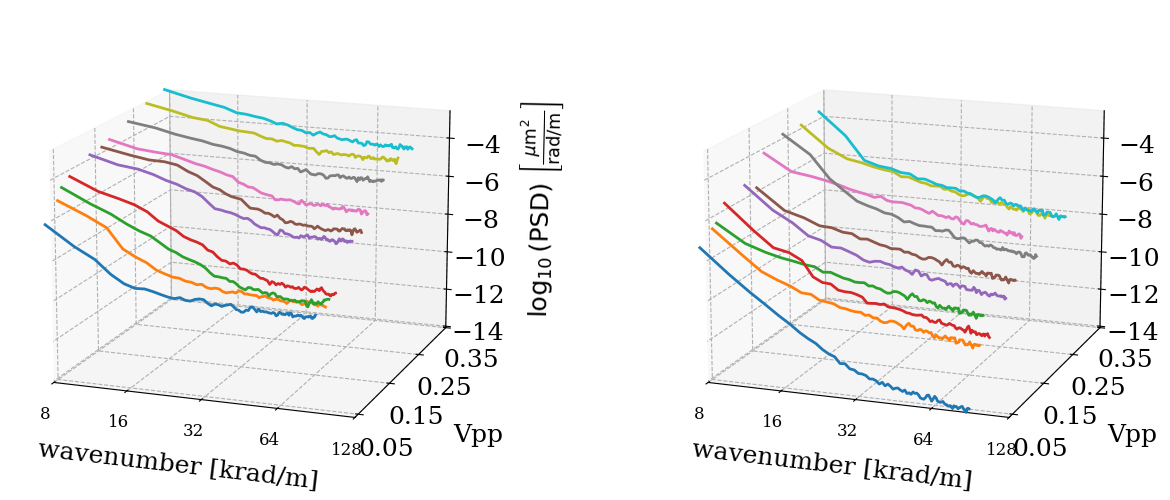

In [191]:
from mpl_toolkits.mplot3d import Axes3D
plt.rcParams["font.family"] = "serif"

vpp_cases = [
    "0p04", "0p07", "0p08", "0p10", "0p15",
    "0p18", "0p20", "0p25", "0p30", "0p35"
]

base_path = "/data/home/hyk049/Wave_Turbulence/"
i_center = 100

vpp_values = [float(c.replace("p", ".")) for c in vpp_cases]

fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(121, projection='3d')
ax2 = fig.add_subplot(122, projection='3d')

z_min, z_max = np.inf, -np.inf

# Experiments
for case, vpp in zip(vpp_cases, vpp_values):

    file_path = f"{base_path}{case}vpp_stoc_opinf_10datasets.mat"
    data = loadmat(file_path)

    EFOM = data['EFOM']
    k_FOM, psd_FOM, *_ = PSD_utils.compute_PSD(EFOM[i_center,:], FS_DHM, 5)

    ax1.plot(np.log2(k_FOM), np.ones_like(k_FOM)*vpp, psd_FOM, lw=2)

    z_min = min(z_min, np.min(psd_FOM))
    z_max = max(z_max, np.max(psd_FOM))

# ROM
for case, vpp in zip(vpp_cases, vpp_values):

    file_path = f"{base_path}{case}vpp_stoc_opinf_10datasets.mat"
    data = loadmat(file_path)

    EROM = data['EROM_opt']
    k_ROM, psd_ROM, *_ = PSD_utils.compute_PSD(EROM[i_center,:], FS_DHM, 10)

    ax2.plot(np.log2(k_ROM), np.ones_like(k_ROM)*vpp, psd_ROM, lw=2)

    z_min = min(z_min, np.min(psd_ROM))
    z_max = max(z_max, np.max(psd_ROM))


k_ticks = np.array([8, 16, 32, 64, 128])
log_k_ticks = np.log2(k_ticks)
y_ticks = [0.05, 0.15, 0.25, 0.35]

for ax in [ax1, ax2]:
    ax.set_xlim(log_k_ticks.min(), log_k_ticks.max())
    ax.set_xticks(log_k_ticks)
    ax.set_xticklabels([str(int(k)) for k in k_ticks], fontsize=12)

    ax.set_ylim(min(vpp_values), max(vpp_values))
    ax.set_yticks(y_ticks)
    ax.set_zlim(z_min, z_max)

    # Increase label padding
    ax.set_xlabel("wavenumber [krad/m]", labelpad=15)
    ax.set_ylabel("Vpp", labelpad=25)
    ax.set_zlabel(r"$\log_{10}(\mathrm{PSD})\ \left[\frac{\mu \mathrm{m}^2}{\mathrm{rad}/\mathrm{m}}\right]$", labelpad=25)


    # Increase tick padding
    ax.tick_params(axis='x', pad=5)
    ax.tick_params(axis='y', pad=8)
    ax.tick_params(axis='z', pad=8)

    ax.view_init(elev=15, azim=-70)

plt.subplots_adjust(left=0.05, right=0.95, bottom=0.1, top=0.9, wspace= 0.08)
plt.show()